ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

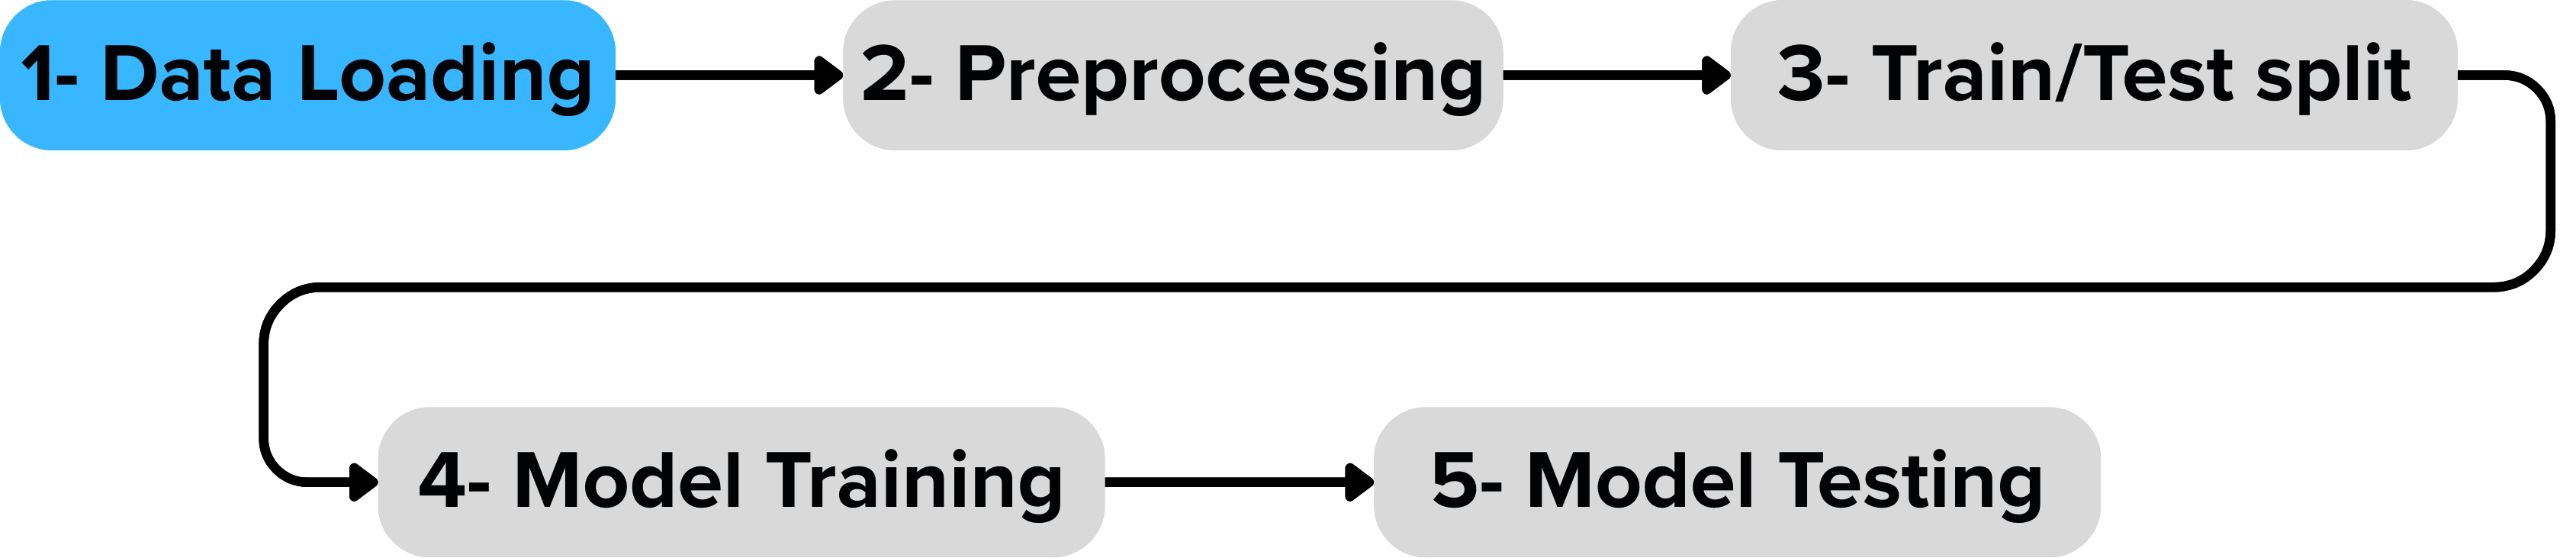

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load the same dataset from Lab 2
df = pd.read_csv("bnpl_dataset.csv")

# Display the first few rows
df.head()

,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Repayment_Status
0,6cbfd4e5-8e91-4a7b-8a14-e3dfa86a3359,56,Male,32293,353,Beauty,Sezzle,249,Defaulted
1,863e8aa6-847e-4ae0-b96b-65241f3450a2,46,Male,72774,354,Groceries,Affirm,188,Paid On Time
2,a24efee2-16f2-42dc-a0e7-6df4960df0b8,32,Male,82207,630,Travel,Sezzle,1610,Paid On Time
3,bbad847a-a92f-4766-ba3f-98b9b199b4cf,60,Male,92498,470,Fashion,Sezzle,120,Paid On Time
4,3f1b1928-09ca-4d06-8ec3-4efd3468d0ec,25,Male,32060,502,Travel,Klarna,1849,Paid On Time


In [21]:
# Load Dataset

df = pd.read_csv("bnpl_dataset.csv")

# Display first 5 rows
df.head()

,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Repayment_Status
0,6cbfd4e5-8e91-4a7b-8a14-e3dfa86a3359,56,Male,32293,353,Beauty,Sezzle,249,Defaulted
1,863e8aa6-847e-4ae0-b96b-65241f3450a2,46,Male,72774,354,Groceries,Affirm,188,Paid On Time
2,a24efee2-16f2-42dc-a0e7-6df4960df0b8,32,Male,82207,630,Travel,Sezzle,1610,Paid On Time
3,bbad847a-a92f-4766-ba3f-98b9b199b4cf,60,Male,92498,470,Fashion,Sezzle,120,Paid On Time
4,3f1b1928-09ca-4d06-8ec3-4efd3468d0ec,25,Male,32060,502,Travel,Klarna,1849,Paid On Time


### Check Missing Values

In [22]:
# Check for missing values to ensure data quality
print("Missing values per column:")
print(df.isnull().sum())

# Generate summary statistics for numerical features
print("\nSummary Statistics:")
display(df.describe())

# Verify data types (e.g., ensure Credit_Score is an integer)
print("\nData Types:")
print(df.dtypes)

Missing values per column:
Transaction_ID       0
Customer_Age         0
Gender               0
Annual_Income        0
Credit_Score         0
Purchase_Category    0
BNPL_Provider        0
Purchase_Amount      0
Repayment_Status     0
dtype: int64

Summary Statistics:


,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,69980.860200,573.569300,563.221980
std,13.528733,28923.444012,158.853766,706.078491
min,18.000000,20000.000000,300.000000,20.000000
25%,29.000000,44915.500000,435.000000,124.000000
50%,41.000000,70071.500000,572.000000,229.000000
75%,53.000000,95262.250000,711.000000,785.000000
max,64.000000,119998.000000,849.000000,2999.000000



Data Types:
Transaction_ID         str
Customer_Age         int64
Gender                 str
Annual_Income        int64
Credit_Score         int64
Purchase_Category      str
BNPL_Provider          str
Purchase_Amount      int64
Repayment_Status       str
dtype: object


In [4]:
print(df.isna().sum())

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


### Check duplicate rows

In [5]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### No. of rows and columns

In [6]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (3282, 6) 

number of rows:  3282
number of columns:  6


### Data type of columns

In [7]:
# viewing the data types of columns
df.dtypes

Sales Person     object
Country          object
Product          object
Date             object
Amount           object
Boxes Shipped     int64
dtype: object

In [12]:
df['Date'] = pd.to_datetime(df['Date'])
df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'])

df.dtypes

/var/folders/cm/4hmh02bx5qj7_2m865h93r040000gn/T/ipykernel_27082/4231514182.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['Date'] = pd.to_datetime(df['Date'])


Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                  float64
Boxes Shipped             int64
dtype: object

### Descriptive summary Statistics

In [13]:
# Statistical summary
df.describe(include='all')

/var/folders/cm/4hmh02bx5qj7_2m865h93r040000gn/T/ipykernel_27082/3456935427.py:2: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df.describe(include='all')


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
count,3282,3282,3282,3282,3282.000000,3282.000000
unique,25,6,22,504,NaN,NaN
top,Kelci Walkden,Australia,50% Dark Bites,2024-01-13 00:00:00,NaN,NaN
freq,162,615,180,16,NaN,NaN
first,NaN,NaN,NaN,2022-01-02 00:00:00,NaN,NaN
last,NaN,NaN,NaN,2024-12-08 00:00:00,NaN,NaN
mean,NaN,NaN,NaN,NaN,6030.338775,164.666971
std,NaN,NaN,NaN,NaN,4393.980200,124.024736
min,NaN,NaN,NaN,NaN,7.000000,1.000000
25%,NaN,NaN,NaN,NaN,2521.495000,71.000000


### Univariate Analysis

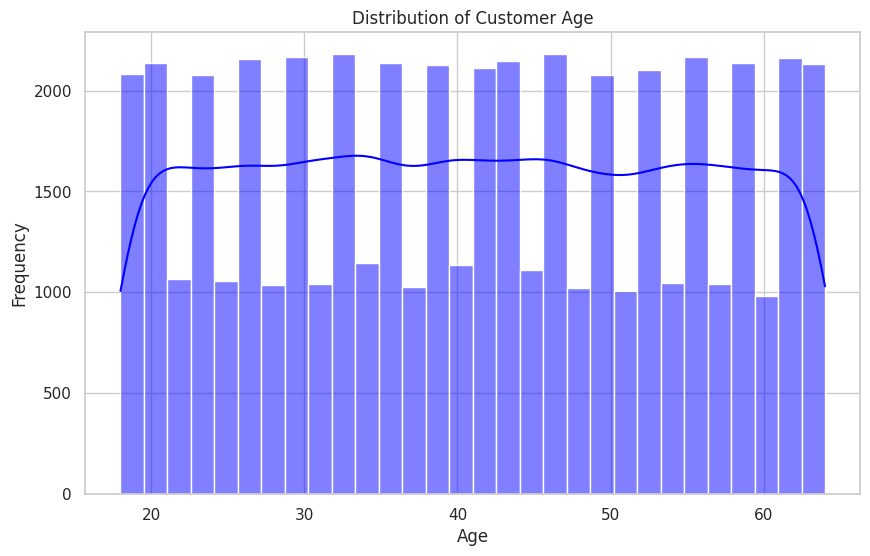

In [23]:
plt.figure(figsize=(10,6))
sns.histplot(df['Customer_Age'], kde=True, bins=30, color='blue')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

- Shows how shipment sizes are distributed
- Right skew = many small shipments, few large ones

### Distribution of Revenue

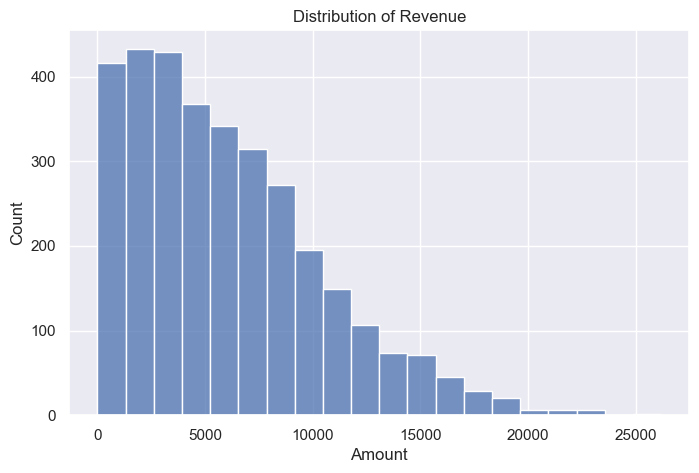

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=20)
plt.title("Distribution of Revenue")
plt.show()

## Bivariate Analysis

### Income by Repayment Status

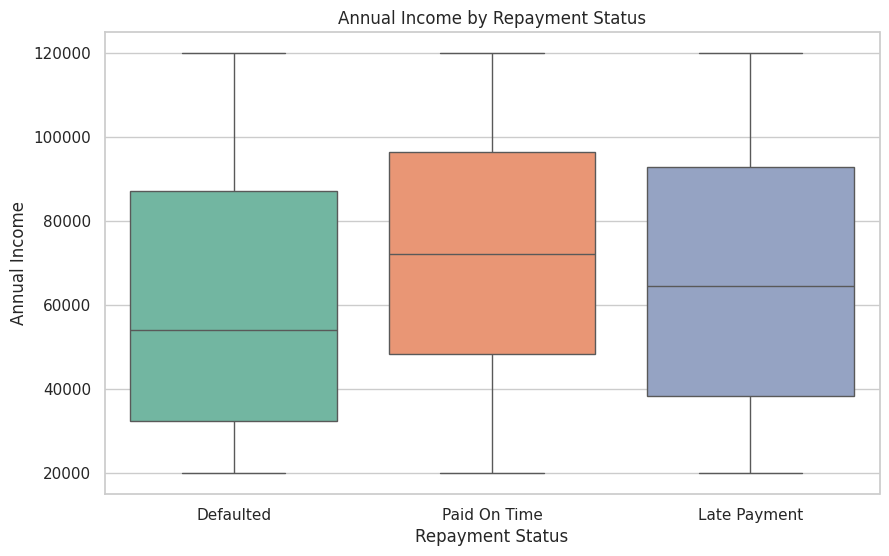

In [25]:
# Updated Bivariate Analysis - Income vs Repayment
plt.figure(figsize=(10,6))
# We assign x to hue to satisfy the new Seaborn requirement
sns.boxplot(x='Repayment_Status', y='Annual_Income', data=df, hue='Repayment_Status', palette='Set2', legend=False)
plt.title('Annual Income by Repayment Status')
plt.ylabel('Annual Income')
plt.xlabel('Repayment Status')
plt.show()

### Category vs Repayment

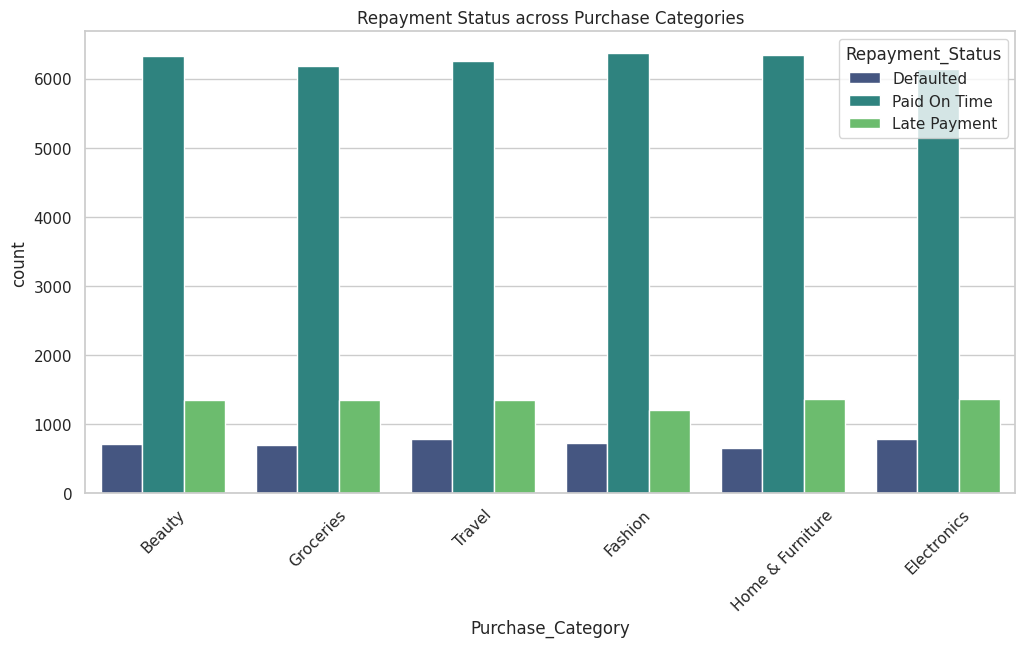

In [26]:
# Updated Bivariate Analysis - Purchase Category vs Repayment
plt.figure(figsize=(12,6))
sns.countplot(x='Purchase_Category', hue='Repayment_Status', data=df, palette='viridis')
plt.title('Repayment Status across Purchase Categories')
plt.xticks(rotation=45)
plt.show()

### Credit Score vs Purchase Amount

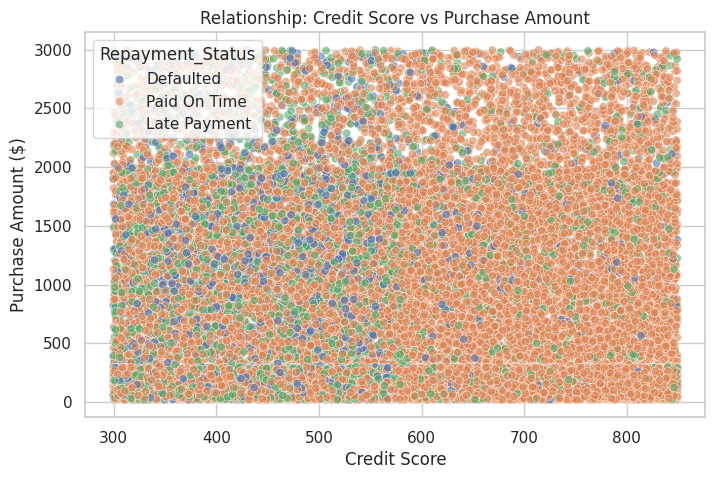

In [28]:
# Instead of Boxes vs Revenue, we look at Credit Score vs Purchase Amount
plt.figure(figsize=(8,5))
sns.scatterplot(x='Credit_Score', y='Purchase_Amount', hue='Repayment_Status', data=df, alpha=0.6)
plt.title("Relationship: Credit Score vs Purchase Amount")
plt.xlabel("Credit Score")
plt.ylabel("Purchase Amount ($)")
plt.show()

### Total Purchase by Category

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


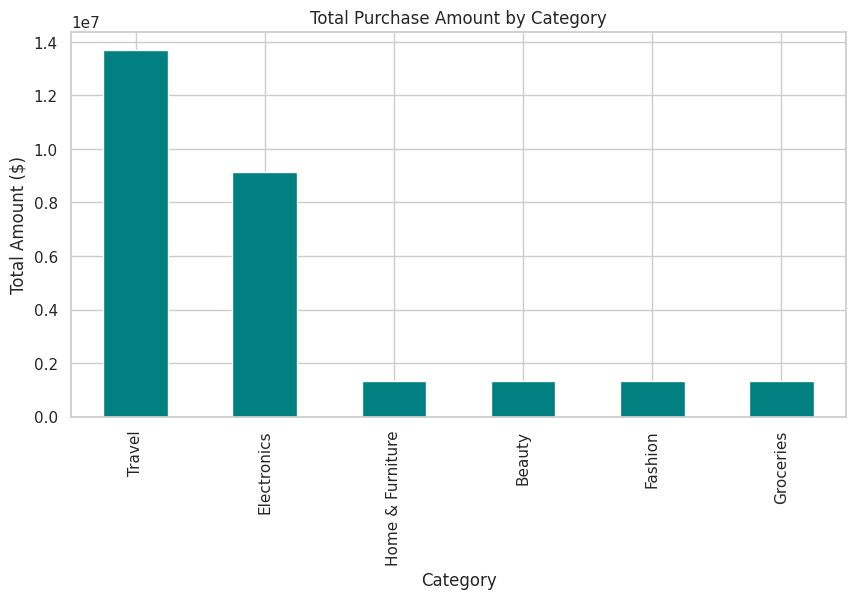

Purchase_Category
Travel              13698230
Electronics          9155487
Home & Furniture     1335027
Beauty               1331483
Fashion              1328141
Groceries            1312731
Name: Purchase_Amount, dtype: int64


In [29]:
# Instead of Sales Person, we see which category has the highest total purchase amount
category_purchase = df.groupby('Purchase_Category')['Purchase_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
category_purchase.plot(kind='bar', color='teal')
plt.title("Total Purchase Amount by Category")
plt.ylabel("Total Amount ($)")
plt.xlabel("Category")
plt.show()

print(category_purchase)

### Correlation Matrix

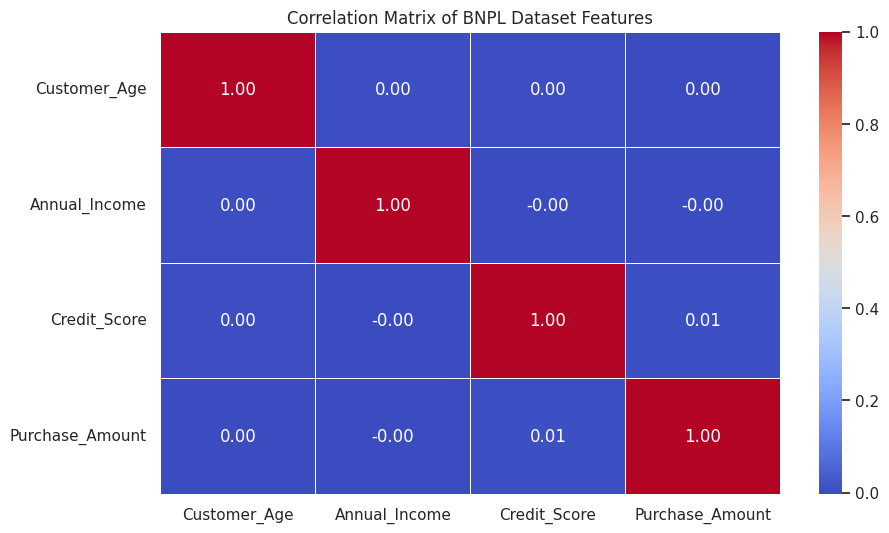

In [27]:
# Create a heatmap to see how numerical features correlate with each other
plt.figure(figsize=(10,6))

# We select only the numeric columns from your BNPL dataset
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

# Plotting the Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of BNPL Dataset Features")
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

## Time-Based Analysis
### Monthly Revenue Trend

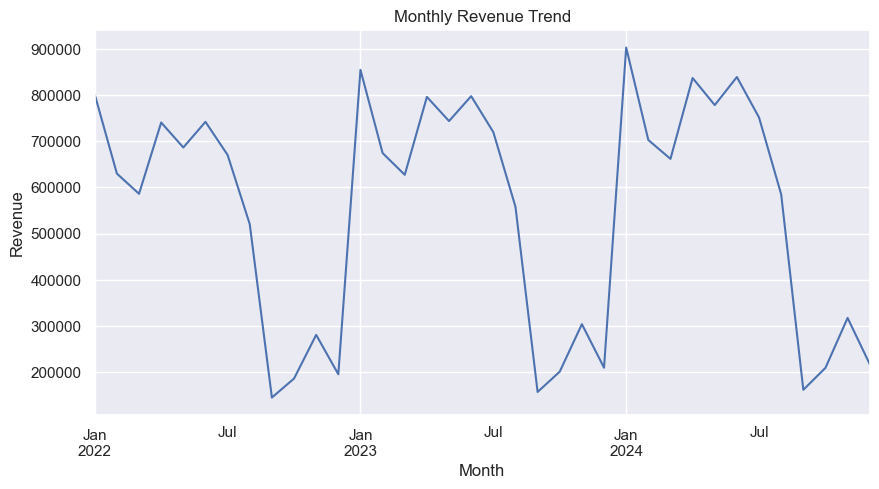

In [21]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the dataset file with your notebook.


End of lab 3.